# M-PESA prediction
<img src="Datasets/Images/MPesaFinance.png" alt="Mental Illness Image" width="500" height="450">
<h2> Case study </h2>

<i><h4>Introduction</i></h4>

* M-Pesa is a mobile money service launched by Safaricom, Kenya’s leading telecommunications company, in 2007. It has revolutionized financial transactions, allowing users to send, receive, deposit, and withdraw money using their mobile phones. M-Pesa has played a significant role in financial inclusion, particularly for unbanked populations.

<i><h4>How M-Pesa Works</h4></i>

* M-Pesa enables users to perform transactions via USSD codes or the M-Pesa app. Users register with Safaricom and link their mobile   numbers to an M-Pesa account. Key services include:
- Depositing money at M-Pesa agent shops.
- Sending money to other users and non-users.
- Withdrawing cash from agents or ATMs.
- Paying bills (electricity, water, internet, school fees, etc.).
- Merchant payments through Lipa na M-Pesa.
- Accessing micro-loans and savings via M-Shwari and KCB M-Pesa.
- Overdraft services using Fuliza.<br>

<i><h4>Challenges and Risks</i></h4>

* High transaction costs: Some users find M-Pesa charges expensive for frequent transactions.
* less finance monitoring and alert on overspending money
* Alternative option on cheaper money spending areas

<i><h4>Solution</i></h4>

* Model a system using m-pesa stament to predict your spending
* provide an alternative of a cheaper spending activity
* provide an alert to user when the spending of money is high(email)

In [5]:
import pandas as pd
import numpy as np
import PyPDF2
import pikepdf
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from tabula.io import read_pdf 
from dateutil import parser 
from sqlalchemy import create_engine
import mysql.connector

In [2]:
# decrepting the file pdf
input_path = "/Users/briankimanzi/Downloads/Mpesa pdfs/Statement_All_Transactions_20240901_20250301.pdf"
output_path = "/Users/briankimanzi/Downloads/Mpesa pdfs/Tracking.pdf"
password = "102030"

with pikepdf.open(input_path, password=password) as pdf:
    pdf.save(output_path)
path = output_path

In [3]:
# getting number of pages on the pdf
with open(path, 'rb') as file:
    pdf_reader = PyPDF2.PdfReader(file)
    num_pages = len(pdf_reader.pages)

In [6]:
# extracting data from mpesa pages
def get_data():
    for page_number in range(1, num_pages+1):
        if page_number == 1:
            df =read_pdf(path, pages=page_number)
            data=df[1]
            return_df =data
        else:
            df = read_pdf(path, pages=page_number)
            data=df[0]

        if page_number != 1:
            return_df = pd.concat([return_df, data])

    return return_df.reset_index(drop=True)
working_data = get_data()

In [ ]:
working_data

In [106]:
# Reading other dataset
Data1 = pd.read_csv('/Users/briankimanzi/Documents/programming Languages/PythonProgramming/JupyterNoteBook/Datasets/katra.csv')
Data2 = pd.read_csv('/Users/briankimanzi/Documents/programming Languages/PythonProgramming/JupyterNoteBook/Datasets/Nashipae.csv')

In [107]:
Data1

,Receipt,transaction_Day,Year,Month,Date,Weekday,Hour,Minute,Seconds,Transaction_type,Transaction_party,Transaction_amount,paid_in_or_Withdraw,Balance
0,TD71R8CU5T,68,2025,4,7,0,12,24,25,AIRTIME PURCHASE,AIRTIME,14.0,WITHDRAW,0.71
1,TD48BNDSIK,67,2025,4,4,4,5,10,29,PAY BILL,SAFARICOM HOME,3699.0,WITHDRAW,96822.71
2,TCU0NDJPKK,66,2025,3,30,6,7,13,23,PAY BILL CHARGES,TRANSACTION COST,10.0,WITHDRAW,27.71
3,TCU0NDJPKK,66,2025,3,30,6,7,13,23,PAY BILL,KPLC PREPAID,1000.0,WITHDRAW,37.71
4,TCS0HGRZ5U,65,2025,3,28,4,20,9,27,AIRTIME PURCHASE,AIRTIME,5.0,WITHDRAW,1037.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,SJC9SXS74T,2,2024,10,12,5,11,49,43,PAY BILL CHARGES,TRANSACTION COST,5.0,WITHDRAW,126.71
131,SJC9SXS74T,2,2024,10,12,5,11,49,43,PAY BILL,KPLC PREPAID,500.0,WITHDRAW,131.71
132,SJB8QWVJN2,1,2024,10,11,4,19,36,51,RECEIVED FUNDS,SAFIA SOYAN,500.0,PAID IN,631.71
133,SJB2QIB142,1,2024,10,11,4,18,34,48,BUSINESS PAYMENT,CO-OP BANK VIA API,120.0,PAID IN,131.71


In [108]:
Data2

,Receipt,transaction_Day,Year,Month,Date,Weekday,Hour,Minute,Seconds,Transaction_type,Transaction_party,Transaction_amount,paid_in_or_Withdraw,Balance
0,TD349XUJFS,154,2025,4,3,3,18,27,59,BUY GOODS,SAWA SHOP 4,65.0,WITHDRAW,1260.75
1,TD399XA2KP,154,2025,4,3,3,18,26,0,BUY GOODS,MOHAMED DULACHA ALI,120.0,WITHDRAW,1325.75
2,TD359WGPPX,154,2025,4,3,3,18,22,0,BUY GOODS,JOANINA KARIMI RUKARIA 6,70.0,WITHDRAW,1445.75
3,TD359Q25IZ,154,2025,4,3,3,17,53,0,PAY BILL CHARGES,TRANSACTION COST,57.0,WITHDRAW,1515.75
4,TD359Q25IZ,154,2025,4,3,3,17,53,0,PAY BILL,CO- OPERATIVE BANK MONEY TRANSFER,10500.0,WITHDRAW,1572.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073,SJ49WDO7A3,1,2024,10,4,4,18,38,59,BUY GOODS,JACKSON MWAURA MUGURO,50.0,WITHDRAW,2330.81
1074,SJ49WC912X,1,2024,10,4,4,18,31,59,BUY GOODS,BK 911 CHICKEN,170.0,WITHDRAW,2380.81
1075,SJ41W9ZSH5,1,2024,10,4,4,18,22,0,BUY GOODS,JUDITH KATHURE MWITI,130.0,WITHDRAW,2550.81
1076,SJ40V94Q5K,1,2024,10,4,4,14,35,59,POCHI LA BIASHARA,MADERINA NYOROKA,50.0,WITHDRAW,2680.81


<h3><i>Data cleaning </i></h3>

In [28]:
# function to remove the commas on the dataset
def remove_comma(x):
    """This function removes commans on the dataset
    parameters: x
    return x
    """
    x = str(x)
    x = x.replace(',', '')
    return x

In [29]:
data = working_data.copy()
data['Paid in'] = data['Paid in'].apply(lambda x: remove_comma(x))
data['Withdraw\rn'] = data['Withdraw\rn'].apply(lambda x : remove_comma(x))
data['Balance'] = data['Balance'].apply(lambda x: remove_comma(x))

In [30]:
# changing data type
data = data.astype({
    'Paid in': float,
    'Withdraw\rn':float,
    'Balance':float
})

In [31]:
# dropping unwanted columns
data.drop(columns=['Unnamed: 0'], inplace=True)

In [32]:
# Anonymising the dataset 
def transaction(x):
    x = str(x).strip()
    if x.startswith('Merchant Payment'):
        index = x.find(' - ')+2
        name = x[index:].strip().upper()
        
        return 'BUY GOODS', name

    elif x.startswith('Deposit of funds'):
        index = x.find(' - ')
        name = x[index:].strip().upper()
        
        return 'AGENT DEPOSIT', name

    elif x.startswith('OD Loan Repayment'):
        return 'FULIZA REPAYMENT', 'FULIZA'

    elif x.startswith('OverDraft of Credit Party'):
        return 'FULIZA TAKEN', 'FULiZA'

    elif x.startswith('M-Shwari Deposit'):
        return 'M-SHWARI DEPOSIT FROM M-PESA', 'M-SHWARI'
        
    elif x.startswith('KCB M-PESA Deposit'):
        return 'KCB M-PESA DEPOSIT FROM M-PESA', 'KCB DEPOSIT'

    elif x.startswith('KCB M-PESA Withdraw'):
        return 'KCB M-PESA WITHDRAW FROM M-PESA', 'KCB WITHDRAW'

    elif x.startswith('Customer Transfer'):
        index = x.find(' - ')
        to_search = x[index:]
        last = 1

        for i in range(len(to_search)):
            try:
                int(to_search[i])
                last = i
                
            except:
                v = 10

        name = x[index+last+2:].strip().upper()
        return 'SEND MONEY', name

    elif x.startswith('M-Shwari Withdraw'):
        
        return 'M-SHWARI WITHDRAW FROM M-PESA', 'M-SHWARI WITHDRAW'

    elif x.startswith('Pay Bill'):
        if x.strip() == 'Pay Bill Charge':
            
            return 'PAY BILL CHARGES', 'TRANSACTION COST'
        else:
            index = x.find(' - ')+2
            end = x.lower().find('acc')
            name = x[index:end].strip().upper()
            
            return 'PAY BILL', name

    elif x.startswith('Funds received'):
        index = x.find(' - ')
        to_search = x[index:]
        last = 1

        for i in range(len(to_search)):
            try:
                int(to_search[i])
                last = i
            except:
                v = 10

        name = x[index+last+2:].strip().upper()
        
        return 'RECEIVED FUNDS', name

    elif x.startswith('Customer Payment to Small Business') or x.startswith('Customer Send Money'):
        index = x.find(' - ')
        to_search = x[index:]
        last = 1

        for i in range(len(to_search)):
            try:
                int(to_search[i])
                last = i
            except:
                v = 10

        name = x[index+last+2:].strip().upper()
        
        return 'POCHI LA BIASHARA', name

    elif x.startswith('Airtime Purchase'):
        return 'AIRTIME PURCHASE', 'AIRTIME'

    elif x.startswith('Business Payment From'):
        index = x.find(' - ')
        end = x.lower().find('via')
        to_search = x[index:]
        last = 1
        name = x[index:end].strip().upper()
        return 'FUNDS RECEIVED FROM BUSINESS', name

    elif x.startswith('Customer Transfer of Funds Charge'):
        return 'TRANSACTION COST', 'TRANSACTION COST'
    
    elif x.startswith('Buy Bundles Online'):
        return 'BUNDLES PURCHASE', 'BUNDES PURCHASE'
    
    elif x.startswith('Customer Withdrawal'):
        index = x.find(' - ')
        name = x[index:].strip().upper()
        return 'CASH WITHDRAWAL', name
    
    elif x.startswith('Withdrawal Charge'):
        return 'CASH WITHDRAWAL CHARGES', "TRANSACTION COST"
    
    elif x.startswith('Savings Contribution'):
        return 'TO HUSTLER FUND SAVINGS', 'HUSTLER FUND'
    
    elif x.startswith('Term Loan Disbursement for H- Fund') or x.startswith('Term Loan Disbursement for H-Fund'):
        return 'HUSTLER FUND Disbursement'.upper(), 'HUSTLER FUND'
    
    elif x.startswith('Term Loan Repayment for H- Fund') or x.startswith('Term Loan Repayment for H-Fund'):
        return 'HUSTLER FUND REPAYMENT', 'HUSTLER FUND'
    
    else:
        return 'UNIDENTIFIED', 'UNIDENTIFIED'

In [33]:
data['Details'] = data['Details'].apply(lambda x: x.replace('\r', ' '))

In [34]:
details = list(data['Details'].apply(lambda x: transaction(x)).values)
transactionType = [i[0] for i in details]
TransactionParty = [i[1] for i in details]

In [ ]:
working_data

In [35]:
# changing the date format
def change_date(date):
    date = parser.parse(date)
    return (date.year, date.month, date.day, date.weekday(),date.hour, date.minute, date.second)

In [36]:
date = data['Completion Time'].apply(lambda x: change_date(x)).values
Year = [i[0] for i in date]
Month = [i[1] for i in date]
Date = [i[2] for i in date]
Weekday = [i[3] for i in date]
Hour = [i[4] for i in date]
Minute = [i[5] for i in date]
Seconds = [i[6] for i in date]

transactionDay = []

reverseDay = Date.copy()[::-1]
datey = reverseDay[0]

d = 1

for i in reverseDay:
    if i == datey:
        transactionDay.append(d)
    else:
        datey = i
        d += 1
        transactionDay.append(d)

transactionDay.reverse()

In [37]:
receipt = list(data['Receipt No'].values)

In [38]:
paid_in = data['Paid in'].fillna('NAN_VALUE').values

In [39]:
def withdrawAmount(x):
    try:
        if x < 0:
            return -x
        else:
            return x
    except:
        return x

In [82]:
withdraw = list(data['Withdraw\rn'].apply(lambda x: withdrawAmount(x)).values)
withdraw                

[80.0,
 1000.0,
 0.0,
 10.0,
 10.0,
 15.0,
 10.0,
 0.0,
 55.0,
 50.0,
 13.0,
 1000.0,
 100.0,
 10.0,
 15.0,
 100.0,
 55.0,
 60.0,
 20.0,
 70.0,
 50.0,
 20.0,
 15.0,
 20.0,
 120.0,
 10.0,
 0.0,
 10.0,
 10.0,
 240.0,
 10.0,
 0.0,
 35.0,
 10.0,
 20.0,
 10.0,
 10.0,
 50.0,
 7.0,
 135.0,
 20.0,
 0.0,
 30.0,
 0.0,
 10.0,
 0.0,
 50.0,
 0.0,
 25.0,
 0.0,
 40.0,
 0.0,
 30.0,
 0.0,
 10.0,
 0.0,
 2000.0,
 0.0,
 20.0,
 20.0,
 50.0,
 100.0,
 10.0,
 0.0,
 50.0,
 0.0,
 50.0,
 0.0,
 50.0,
 0.0,
 50.0,
 10.0,
 75.0,
 0.0,
 10.0,
 2.0,
 5.0,
 0.0,
 2.0,
 40.0,
 80.0,
 100.0,
 0.0,
 20.0,
 0.0,
 100.0,
 100.0,
 0.0,
 30.0,
 145.0,
 0.0,
 250.0,
 0.0,
 0.0,
 60.0,
 80.0,
 10.0,
 7.0,
 130.0,
 0.0,
 100.0,
 7.0,
 300.0,
 0.0,
 3.0,
 50.0,
 0.0,
 70.0,
 10.0,
 0.0,
 10.0,
 200.0,
 0.0,
 50.0,
 7.0,
 200.0,
 0.0,
 4800.0,
 0.0,
 10.0,
 70.0,
 60.0,
 0.0,
 100.0,
 15.0,
 10.0,
 20.0,
 10.0,
 10.0,
 7.0,
 150.0,
 20.0,
 0.0,
 15.0,
 15.0,
 15.0,
 20.0,
 10.0,
 10.0,
 10.0,
 15.0,
 15.0,
 20.0,
 50.0,
 10.0,
 2

In [41]:
transaction_Data = []

for i in range(len(paid_in)):
    try:
        x = float(paid_in[i])
        transaction_Data.append((x, 'PAID IN'))
    except:
        x = float(withdraw[i])
        transaction_Data.append((x, 'WITHDRAW'))

In [42]:
transaction_amount = [i[0] for i in transaction_Data]
paid_in_or_withdraw = [i[1] for i in transaction_Data]

In [43]:
balance =list(data["Balance"].values)

In [83]:
final_data = pd.DataFrame({
    "Receipt":receipt,
    "transaction_Day": transactionDay,
    "Year" : Year,
    "Month" : Month,
    "Date" : Date,
    "Weekday" : Weekday,
    "Hour" : Hour,
    "Minute" : Minute,
    "Seconds" : Seconds,
    "Transaction_type" : transactionType,
    "Transaction_party" : TransactionParty,
    "Transaction_amount" : transaction_amount,
    "paid_in_or_Withdraw" : paid_in_or_withdraw,
    "Balance" : balance
})
final_data.set_index('Receipt', inplace=True)
final_data

,transaction_Day,Year,Month,Date,Weekday,Hour,Minute,Seconds,Transaction_type,Transaction_party,Transaction_amount,paid_in_or_Withdraw,Balance
Receipt,,,,,,,,,,,,,
TC17XS3U67,49,2025,3,1,5,15,55,18,SEND MONEY,GIDEON KIPAMET KAIYIAN,0.0,PAID IN,27.0
TC14XHM64C,49,2025,3,1,5,14,49,55,M-SHWARI DEPOSIT FROM M-PESA,M-SHWARI,0.0,PAID IN,107.0
TC11XF54B3,49,2025,3,1,5,14,34,40,RECEIVED FUNDS,SHEILA MERCY NDUSYA,1100.0,PAID IN,1107.0
TC13WSE6N5,49,2025,3,1,5,12,11,53,PAY BILL,TINGG,0.0,PAID IN,7.0
TBS1THWSOL,48,2025,2,28,4,17,50,41,SEND MONEY,NAOMI NYAMBURA MBURU,0.0,PAID IN,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAB3U80KYL,2,2025,1,11,5,20,34,49,M-SHWARI WITHDRAW FROM M-PESA,M-SHWARI WITHDRAW,50.0,PAID IN,79.0
TAA7PUAYUX,1,2025,1,10,4,20,19,56,PAY BILL CHARGES,TRANSACTION COST,0.0,PAID IN,29.0
TAA7PUAYUX,1,2025,1,10,4,20,19,56,PAY BILL,DIRECT PAY LIMITED 1,0.0,PAID IN,31.0


In [109]:
# joining all the datasets together
Data1.reset_index(inplace=True)
Data2.reset_index(inplace=True)
final_data.reset_index(inplace=True)

In [120]:
combined_data = pd.concat([final_data, Data1, Data2], ignore_index=True)

In [121]:
combined_data.set_index('Receipt', inplace=True)

In [92]:
combined_data.drop(columns='index', errors='coerce', inplace=True)

In [122]:
combined_data

,transaction_Day,Year,Month,Date,Weekday,Hour,Minute,Seconds,Transaction_type,Transaction_party,Transaction_amount,paid_in_or_Withdraw,Balance
Receipt,,,,,,,,,,,,,
TC17XS3U67,49,2025,3,1,5,15,55,18,SEND MONEY,GIDEON KIPAMET KAIYIAN,0.0,PAID IN,27.00
TC14XHM64C,49,2025,3,1,5,14,49,55,M-SHWARI DEPOSIT FROM M-PESA,M-SHWARI,0.0,PAID IN,107.00
TC11XF54B3,49,2025,3,1,5,14,34,40,RECEIVED FUNDS,SHEILA MERCY NDUSYA,1100.0,PAID IN,1107.00
TC13WSE6N5,49,2025,3,1,5,12,11,53,PAY BILL,TINGG,0.0,PAID IN,7.00
TBS1THWSOL,48,2025,2,28,4,17,50,41,SEND MONEY,NAOMI NYAMBURA MBURU,0.0,PAID IN,17.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
SJ49WDO7A3,1,2024,10,4,4,18,38,59,BUY GOODS,JACKSON MWAURA MUGURO,50.0,WITHDRAW,2330.81
SJ49WC912X,1,2024,10,4,4,18,31,59,BUY GOODS,BK 911 CHICKEN,170.0,WITHDRAW,2380.81
SJ41W9ZSH5,1,2024,10,4,4,18,22,0,BUY GOODS,JUDITH KATHURE MWITI,130.0,WITHDRAW,2550.81


In [123]:
# connecting to the database
DB_USER = "root"
DB_PASSWORD = "673gezmigel"
DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "mpesa"

# creating engine
engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
# test connection

try:
    with engine.connect() as conn:
        print("Connection to database is 👍🏼")
        
    combined_data.reset_index(inplace = True)
    combined_data.to_sql(name='Mpesa_Statement', con=engine, if_exists='replace', index=False)
    
except Exception as e:
    print(f"connection Failed {e} 👎🏼")

Connection to database is 👍🏼


,Receipt,transaction_Day,Year,Month,Date,Weekday,Hour,Minute,Seconds,Transaction_type,Transaction_party,Transaction_amount,paid_in_or_Withdraw,Balance
0,TD71R8CU5T,68,2025,4,7,0,12,24,25,AIRTIME PURCHASE,AIRTIME,14.0,WITHDRAW,0.71
1,TD48BNDSIK,67,2025,4,4,4,5,10,29,PAY BILL,SAFARICOM HOME,3699.0,WITHDRAW,96822.71
2,TCU0NDJPKK,66,2025,3,30,6,7,13,23,PAY BILL CHARGES,TRANSACTION COST,10.0,WITHDRAW,27.71
3,TCU0NDJPKK,66,2025,3,30,6,7,13,23,PAY BILL,KPLC PREPAID,1000.0,WITHDRAW,37.71
4,TCS0HGRZ5U,65,2025,3,28,4,20,9,27,AIRTIME PURCHASE,AIRTIME,5.0,WITHDRAW,1037.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,SJC9SXS74T,2,2024,10,12,5,11,49,43,PAY BILL CHARGES,TRANSACTION COST,5.0,WITHDRAW,126.71
131,SJC9SXS74T,2,2024,10,12,5,11,49,43,PAY BILL,KPLC PREPAID,500.0,WITHDRAW,131.71
132,SJB8QWVJN2,1,2024,10,11,4,19,36,51,RECEIVED FUNDS,SAFIA SOYAN,500.0,PAID IN,631.71
133,SJB2QIB142,1,2024,10,11,4,18,34,48,BUSINESS PAYMENT,CO-OP BANK VIA API,120.0,PAID IN,131.71


# <i>Extrapolatory Data Analysis</i>
* <h3>Finding insight and correlation on dataset by answering the following question</h3>

- What day of the week do I spend the most money?  
- How does spending vary across different months or years?
- <i> Line chart of Month vs total Transaction_amount, grouped by Year.</i>
- At what time of day do most transactions happen?
- <i> Histogram of Hour or a 24-hour clock radial chart.</i>
- Is there a particular week or date where spending spikes?
- <i> Time series plot using Date + Transaction_amount.</i>

<h3> 💸 Spending Patterns</h3>

- Which transaction types (e.g., Buy Goods, PayBill, Withdraw) do I use most?
- <i> Pie or bar chart from Transaction_type.</i>
- What’s the average transaction amount by type?
- <i> Grouped bar chart: Transaction_type vs average Transaction_amount.</i>
- Are there more cash-ins (Received) or cash-outs (Withdrawals)?
- <i> Comparison chart from paid_in_or_Withdraw.</i>

<h3> 👤 People or Places You Transact With</h3>

- Which parties do I send/receive money to/from the most?
- <i> Bar chart: top 10 Transaction_party by frequency or total amount.</i>
- Who do I spend the most money on?
- <i>Same as above but filter paid_in_or_Withdraw == 'Withdraw'.</i>

<h3> 📉 Balance & Financial Health</h3>

- What’s my balance trend over time?
- <i> Line chart of Date vs Balance.</i>
- How often do I hit low balances after big transactions?
- <i> Scatter plot of Transaction_amount vs Balance post-transaction.</i>



In [124]:
Column, rows = combined_data.shape
print(f"Columns: {Column} Rows: {rows}")

Columns: 1487 Rows: 14


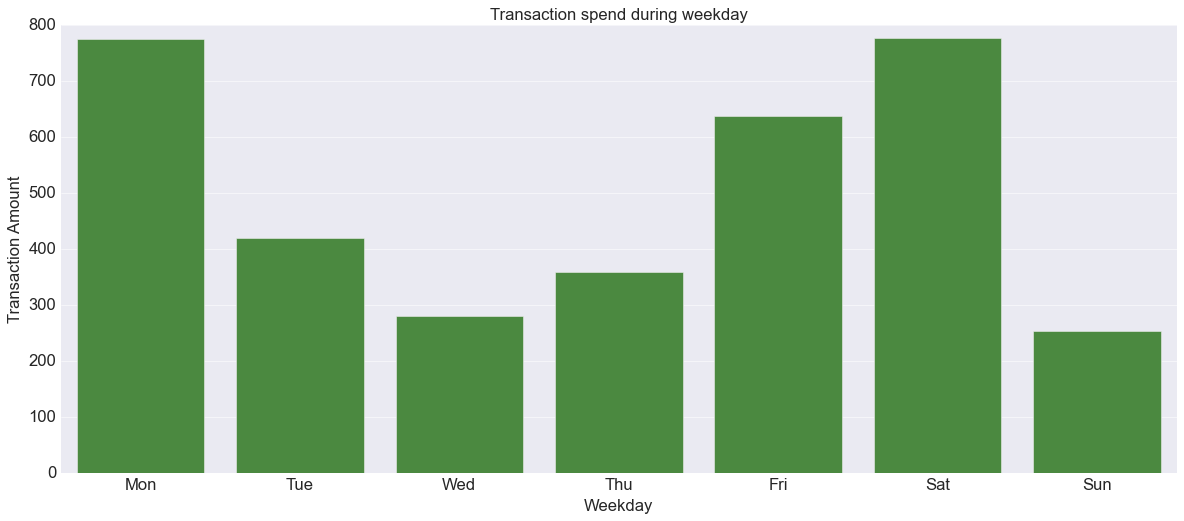

In [195]:
# What day of the week do I spend the most money?
# mpesa color code #439534
plt.figure(figsize=(18, 7))
plt.style.use('seaborn-v0_8-darkgrid')
plot = sns.barplot(data=combined_data,
            x='Weekday',  y='Transaction_amount', color='#439534', errorbar=None,
           )
plt.title('Transaction spend during weekday', fontsize=15)
plt.xlabel('Weekday', fontsize=15)
plt.xticks(fontsize=15)
plt.ylabel('Transaction Amount', fontsize=15)
plt.yticks(fontsize=15)
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plot.set_xticklabels([weekday_names[i] for i in plot.get_xticks()])
plt.show()

In [ ]:
# How does spending vary across different months or years?
